In [1]:
using Pkg
Pkg.activate("..")

using CairoMakie
using ColorSchemes
using LinearAlgebra
using Combinatorics
using Graphs
using Distributions
using Roots
using Random
using StatsBase

include("../Code/PlantPol.jl/PlantPol.jl")

  Activating project at `~/Projects/Working/HIFMB/Polinators`


Main.PlantPol

# Introduction

In this notebook I will go through the plant-pollinator model.

# Simple Bipartite Percolation

In [3]:
Random.seed!(1)
z = 2.0
#prediction
G(x) = exp(z*(x-1))

function f_sol(x)
    a = 1 - G(1-x)
    return 1 - G(1-a)- x
end

pred = find_zeros(f_sol,0,1)

#simulations
N = 10000

ka = rand(Poisson(z), N)
kp = rand(Multinomial(sum(ka), N))

a_ind = inverse_rle(1:N, ka) |> shuffle
p_ind = inverse_rle(1:N, kp) |> shuffle

g = SimpleGraph(2N)

for (i,j) = zip(a_ind,p_ind)
    add_edge!(g, i, N + j)
end

s = rand(2N) .< 0.001

for t = 1:100
    for i = shuffle(1:2N)
        s[i] = any(s[g.fadjlist[i]])
    end
end

sim = s[1:N]

println("predicted: ",pred)
println("sim: ",sim |> mean)

predicted: [0.0, 0.7968121300200199]
sim: 0.7931


# (quasi)Temporal Bipartite Percolation
Pollinator links are labeled in time but no temporal structure is enforced

In [4]:
Random.seed!(1)
z = 2.5
τ = 3.0
#prediction
G(x) = exp(z*(x-1))
L(x) = x*exp(τ*(x-1))

function f_sol(x)
    p = 1 - G(1 - x)
    return L(1 - G( 1 - p)) - x
end

pred = find_zeros(f_sol,0,1);

In [5]:
#simulations
M = 10000

la = 1 .+ rand(Poisson(τ), M)
ka = [rand(Poisson(z), la[i]) for i = 1:M]

#plant node number
N = floor(Int, M * (1+τ))
#sample plant degree
kp = rand(Multinomial(sum(sum.(ka)), N))
#get plant degree stubs
p_stub = inverse_rle(1:N, kp) |> shuffle

#dict to store edges + groups
edge_ind = Dict{Int, Vector{Int}}(i => [] for i = 1:M)
edge_group = Dict{Int, Dict{Int,Vector{Int}}}(i => Dict() for i = 1:M)
#graph for structure
g = SimpleGraph(M + N)
p_index = 1
#loop over all pollinators
for i = 1:M
    #for each edge group
    for (t,k) = enumerate(ka[i])
        edge_group[i][t] = []
        #loop over size
        for j = 1:k
            #add p_stub + cycle through
            push!(edge_group[i][t], M + p_stub[p_index])
            push!(edge_ind[i], M + p_stub[p_index])
            #add edge to grap
            add_edge!(g, i, M + p_stub[p_index])
            p_index += 1 
        end
    end
end


In [6]:
function simulate(n)
    con = connected_components(g)
    gc = con[findmax(length.(con))[2]]
    filter!(x -> x .<= M, gc)
    s = falses(N+M) 
    s[rand(gc,n)] .= 1
    
    stmp = similar(s)
    pol_node = vcat(trues(M),falses(N))
    
    τ = 0
    while (sum(s .⊻ stmp) > 0) && τ < 1000
        copyto!(stmp, s)
        for i = shuffle(eachindex(s))
            if !s[i]
                if pol_node[i]
                    s[i] = true
                    for (t,v) = edge_group[i]
                        if !any(stmp[v])
                            s[i] = false
                            break
                        end
                    end
                else
                    s[i] = any(stmp[g.fadjlist[i]])
                end
            end
        end
        τ += 1
    end
    return(s[1:M] |> mean)
end

println("predicted: ",pred)
println("sim: ",simulate(500))


predicted: [0.0, 0.188250269651618, 0.5069978724122192]
sim: 0.0897


# Temporal Bipartite Percolation
Pollinator links are labeled in time but temporal structure *is* enforced

In [8]:
include("../Code/PlantPol.jl/PlantPol.jl")

Main.PlantPol

In [9]:
#testing
# Random.seed!(3)

T = 50
Mt = 1000
z = 3.0
τ = 3.0

fa(x) = PlantPol.a_sol(x,z,z,τ)
@time pred = find_zeros(fa, 0, 1)

N,M,fadj = PlantPol.build_network(z,τ,T,Mt);
@time sim_assembly = PlantPol.simulate_network(0.01,N,M,fadj)[1:M] |> mean

println("predicted: ", pred)
println("simulated: ", sim_assembly)

  0.211621 seconds (237.02 k allocations: 12.509 MiB, 99.43% compilation time)
  1.785169 seconds (199.71 k allocations: 46.688 MiB, 3.76% gc time, 10.38% compilation time)
predicted: [0.0, 0.05547164941320598, 0.7612886384862797]
simulated: 0.16294290227939517


In [10]:
K = 5
z_vec = range(0.01,2.0, length = K)
τ_vec = range(0.01,2.0, length = K)

res_sim = zeros(K,K)
res_pred = Matrix{Any}(undef,K,K)

Threads.@threads for i = 1:K
    for j = 1:K
        N,M,fadj = PlantPol.build_network(z_vec[i],τ_vec[j],T,Mt)
        res_sim[i,j] = PlantPol.simulate_network(0.01, N, M, fadj)[1:M] |> mean

        fa(x) = PlantPol.a_sol(x,z_vec[i],z_vec[i],τ_vec[j])
        res_pred[i,j] = find_zeros(fa, 0, 1)
    end
end

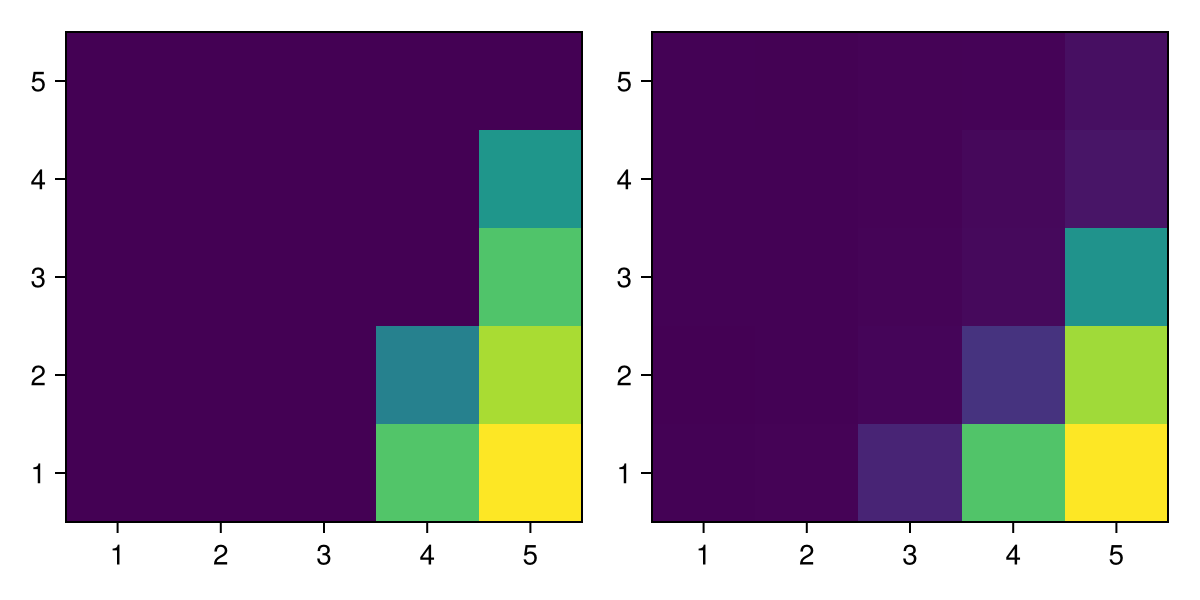

In [11]:
fig = Figure(size = (600,300))

ax = Axis(fig[1,1])
heatmap!(ax, maximum.(res_pred))
ax = Axis(fig[1,2])
heatmap!(ax, maximum.(res_sim))

fig

## Full phase plot

In [11]:
K = 200
z_vec = range(0.01,4.0, length = K)
τ_vec = range(0.01,3.0, length = K)


results_pred_a = Array{Any,2}(undef,K,K)
results_pred_p = similar(results_pred_a)
results_pred_static = similar(results_pred_a)

Threads.@threads for i = 1:K
    for j = 1:K
        fa(x) = PlantPol.a_sol(x,z_vec[i],z_vec[i],τ_vec[j])
        results_pred_a[i,j] = find_zeros(fa, 0, 1)
        
        fp(x) = PlantPol.p_sol(x,z_vec[i],z_vec[i],τ_vec[j])
        results_pred_p[i,j] = find_zeros(fp, 0, 1)

        f_static(x) = PlantPol.a_sol_static(x,z_vec[i],z_vec[i],τ_vec[j])
        results_pred_static[i,j] = find_zeros(f_static, 0, 1)
    end
end

In [23]:
#system size
T = 10
Mt = 10000

#simulation parameters
R = 20
Ksim = 25
z_vec_sim = range(extrema(z_vec)..., length = Ksim)
τ_vec_sim = range(extrema(τ_vec)..., length = Ksim)

#l transects
high = 2.5
high_ind = findmin(abs.(τ_vec .- high))[2]
high = τ_vec[high_ind]

low = 0.5
low_ind = findmin(abs.(τ_vec .- low))[2]
low = τ_vec[low_ind]

#run simualtions
results_sim = Array{Any,3}(undef,2,Ksim,R)
for i = 1:Ksim        

        N,M,fadj = PlantPol.build_network(z_vec_sim[i],high, T,Mt)
        for r = 1:R
            x0 = 0.02 * rand()
            results_sim[1,i,r] = PlantPol.simulate_network(x0, N, M, fadj)[1:M] |> mean 
        end

        N,M,fadj = PlantPol.build_network(z_vec_sim[i],low,T,Mt)
        for r = 1:R
            x0 = 0.02 * rand()
            results_sim[2,i,r] = PlantPol.simulate_network(x0, N, M, fadj)[1:M] |> mean 
        end
end

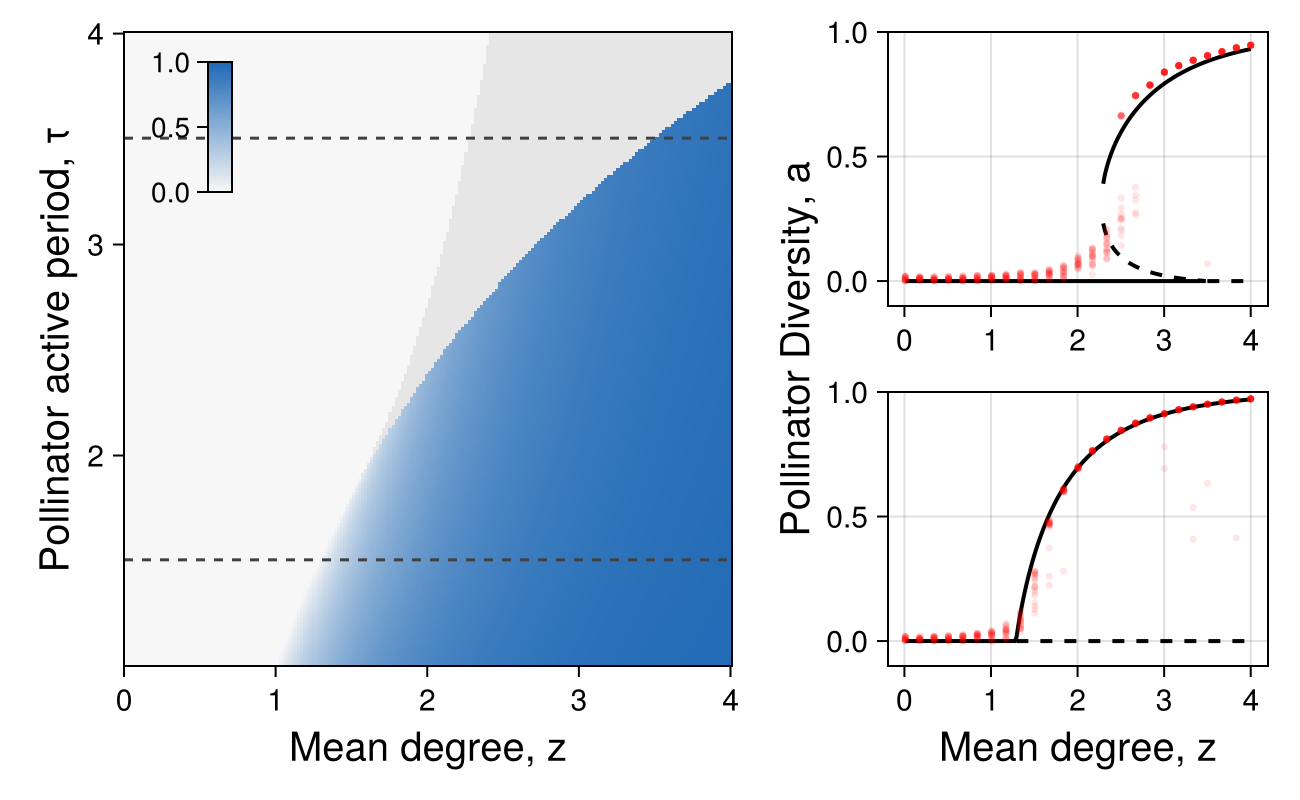

In [26]:
style = Dict(:xlabelsize => 20, :ylabelsize => 20, :xticklabelsize => 15, :yticklabelsize => 15)

fig = Figure(size = (650,400))
ax = Axis(fig[1:2,1], xlabel = "Mean degree, z", ylabel = "Pollinator active period, τ", xgridvisible = 0, ygridvisible = 0; style...)

c1 = RGBf(0.97,0.97,0.97)
c0 = RGBf(0.12,0.41,0.71)
cm = ColorScheme(range(c1,c0, length = 100))

#get heatmap colors
col_matrix = map(results_pred_a) do (res)    
    
    if length(res) != 3
        uv = maximum(res)
        r = c0.r * uv + c1.r * (1 - uv)
        g = c0.g * uv + c1.g * (1 - uv)
        b = c0.b * uv + c1.b * (1 - uv)

        return RGBf(r,g,b)
    else
        return RGBf(0.9, 0.9, 0.9)
    end
end

green_col = RGBf(0.5, 0.78, 0.47)
blue_col = RGBf(0.09, 0.64, 0.86)

heatmap!(ax, z_vec, 1 .+ τ_vec, col_matrix)
Colorbar(fig[1:2,1], colormap = cm, flipaxis = false, vertical = true, 
    height = Relative(0.3), halign = :left, valign = :top, alignmode = Outside(15))

hlines!(ax, 1 .+ [low,high], color = :gray25, linestyle = :dash)

ax_title = Axis(fig[1:2,2], ylabel = "Pollinator Diversity, a", ylabelpadding = 35, spinewidth = 0; style...)
hidedecorations!(ax_title, label = false)


ax2 = Axis(fig[1,2]; style...)
PlantPol.plot_bifurcation_diagram!(ax2, z_vec, results_pred_a[:,high_ind], color = :black, linewidth = 2)
for i = 1:Ksim
    scatter!(ax2, fill(z_vec_sim[i], R), results_sim[1,i,:], color = (:red, 0.1), markersize = 5)
end

ax3 = Axis(fig[2,2], xlabel = "Mean degree, z"; style...)
PlantPol.plot_bifurcation_diagram!(ax3, z_vec, results_pred_a[:,low_ind], color = :black, linewidth = 2)
for i = 1:Ksim
    scatter!(ax3, fill(z_vec_sim[i], R), results_sim[2,i,:], color = (:red, 0.1), markersize = 5)
end

ylims!.([ax2,ax3],-0.1, 1)

colgap!(fig.layout, 20)
colsize!(fig.layout, 1, Relative(400 / 650))

fig

In [49]:
save("../figures/Fig1.pdf",fig)

CairoMakie.Screen{PDF}


## Temporal structure
What is the effect of including this temporal structure?

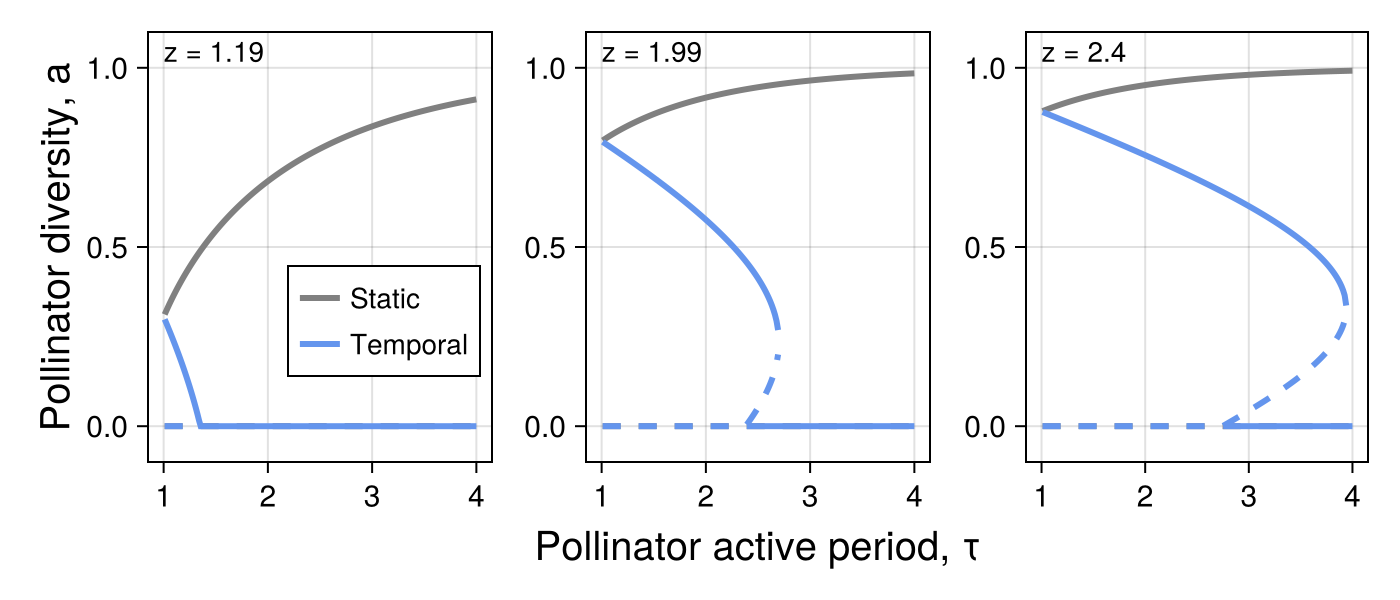

In [269]:
style = Dict(:xlabelsize => 20, :ylabelsize => 20, :xticklabelsize => 15, :yticklabelsize => 15)


fig = Figure(size = (700,300))
ax = Axis(fig[1,1:3], xlabel = "Pollinator active period, τ", ylabel = "Pollinator diversity, a", spinewidth = 0, xlabelpadding = 30, ylabelpadding = 35; style...)
hidedecorations!(ax, label = false)

for (i,v) = enumerate([60,100,120])
    ax = Axis(fig[1,i];  style...)
    ylims!(ax, -0.1, 1.1)
    PlantPol.plot_bifurcation_diagram!(ax, 1 .+ τ_vec, results_pred_static[v,:], color = :grey, linewidth = 3, label = "Static")
    PlantPol.plot_bifurcation_diagram!(ax, 1 .+ τ_vec, results_pred_a[v,:], color = :cornflowerblue, linewidth = 3, label = "Temporal")
    z = round(z_vec[v],digits = 2)
    text!(ax,1.0,1.0; text = "z = $z")
end

axislegend(fig.content[2], unique = true, position = (1.0,0.25))

fig

In [270]:
save("../figures/Fig2.pdf",fig)

CairoMakie.Screen{PDF}


In [271]:
function split_at_discontinuities(x::AbstractVector, y::AbstractVector; threshold::Real=0.5)
    # Ensure inputs are not empty
    if isempty(x) || isempty(y)
        return []
    end
    if length(x) != length(y)
        error("x and y vectors must have the same length.")
    end
    
    segments = []
    start_index = 1
    
    for i in 1:(length(y) - 1)
        
        if abs(y[i+1] - y[i]) > threshold
            push!(segments, (x[start_index:i], y[start_index:i]))
            start_index = i + 1
        end
    end

    push!(segments, (x[start_index:end], y[start_index:end]))

    return segments
end

function cumtrapz(X::T, Y::T) where {T <: AbstractVector}
  # Check matching vector length
  @assert length(X) == length(Y)
  # Initialize Output
  out = similar(X)
  out[1] = 0
  # Iterate over arrays
  for i in 2:length(X)
    out[i] = out[i-1] + 0.5*(X[i] - X[i-1])*(Y[i] + Y[i-1])
  end
  # Return output
  out
end


cumtrapz (generic function with 1 method)

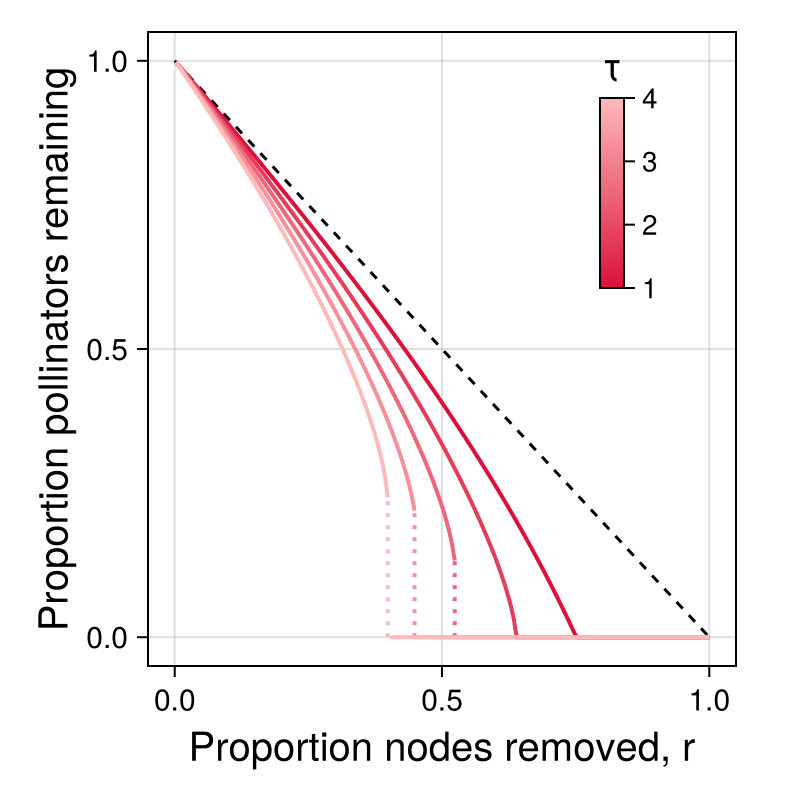

In [277]:
style = Dict(:xlabelsize => 20, :ylabelsize => 20, :xticklabelsize => 15, :yticklabelsize => 15)

fig = Figure(size=(400,400))
ax = Axis(fig[1,1], xlabel = "Proportion nodes removed, r", ylabel = "Proportion pollinators remaining"; style...)



lines!(ax, [0,1], [1,0], color = :black, linestyle = :dash)

c1 = RGBf(0.86,0.07,0.23)
c0 = RGBf(1.0,0.73,0.73)
cm = ColorScheme(range(c1,c0, length = 100))
cvec = resample_cmap(cm, 5)

for (i,k) = enumerate([1,50,100,150,200])
    y_vec = maximum.(results_pred_a[:,k])
    y_vec = y_vec ./ maximum(y_vec)
    x_vec = reverse(z_vec ./ maximum(z_vec))
    y_vec .*= (1 .- x_vec)
    
    l = split_at_discontinuities(x_vec, y_vec; threshold=0.05)
    for j = eachindex(l)
        lines!(ax, l[j][1], l[j][2], color = (cvec[i], 1.0), linewidth = 2)
    end

    if length(l) > 1
        for j = 2:length(l)
            x_vec = l[j][1][1]
            y_vec = [l[j-1][2][1],l[j][2][1]]

            lines!(ax, [x_vec, x_vec], y_vec, color = (cvec[i],1.0), linestyle = :dot, linewidth = 2)
        end
    end    
end

Colorbar(fig[1,1], colormap = cm, colorrange = (1.0, 4.0) ,tellwidth = false, tellheight = false, 
    height = Relative(0.3), valign = 0.85, halign = 0.8)
text!(ax, 0.8,0.95, text = "τ", fontsize = 20)


fig




In [278]:
save("../figures/Fig3.pdf",fig)

CairoMakie.Screen{PDF}


In [282]:
using DelimitedFiles
data = readdlm("../Data/rockies/caradonna_rmbl_flowering_phenology_data_EDI.csv",',');

In [317]:
plants = data[2:end,3] |> unique
sites = data[2:end,2] |> unique
times = data[2:end,5] |> unique


a_mat = zeros(length(plants), length(sites), length(times))

for i = eachindex(plants)
    for j = eachindex(sites)
        for k = eachindex(times)
            ind = (data[2:end,3] .== plants[i]) .&& (data[2:end,2] .== sites[j]) .&& (data[2:end,5] .== times[k]) 
            if sum(ind) != 0
                a_mat[i,j,k] = sum(data[2:end,6][ind])
            end
        end
    end
end


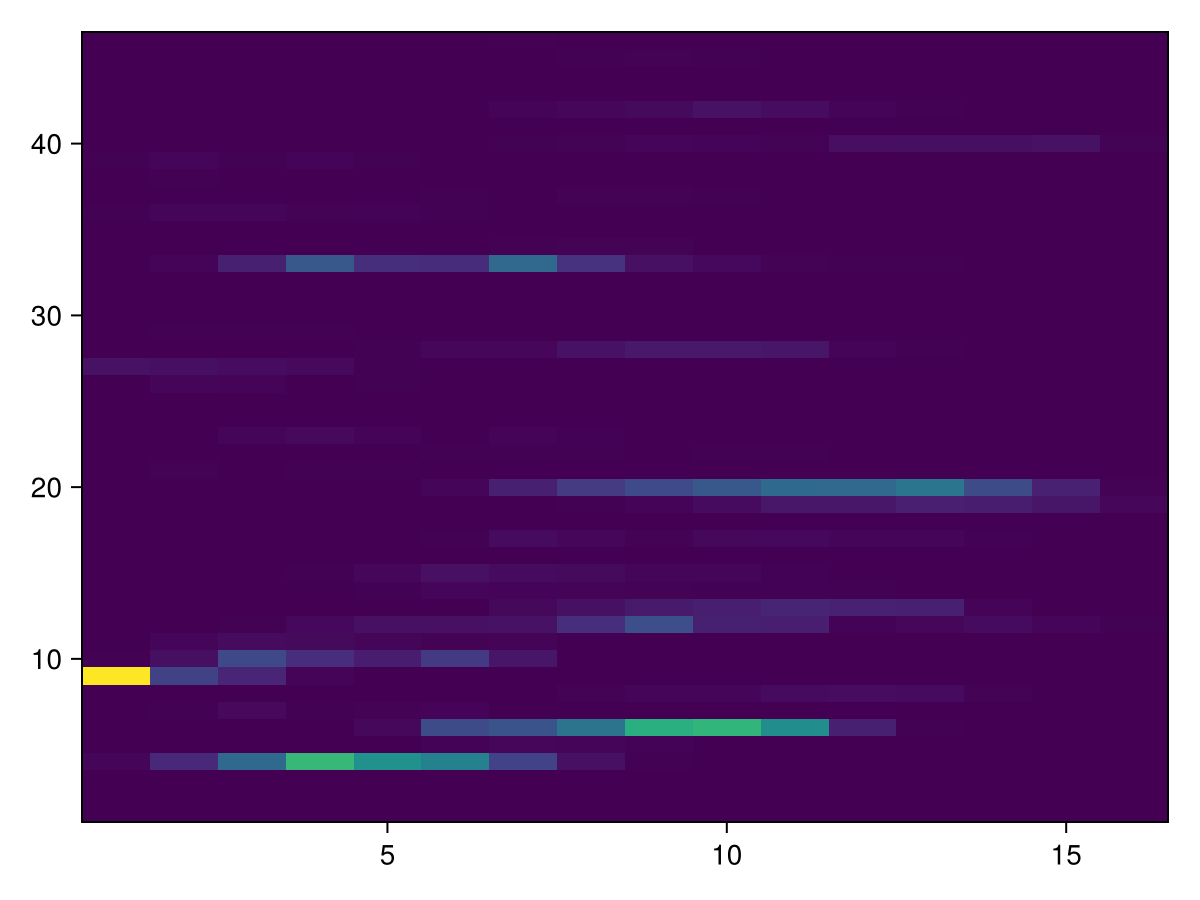

In [318]:
a_mat[:,1,:]' |> heatmap

In [335]:
data_interaction[1,:]

16-element Vector{Any}:
 "year"
 "date"
 "day_of_year"
 "week_num"
 "site"
 "transect"
 "start_time"
 "end_time"
 "plant"
 "pollinator"
 "interactions"
 "pollinator_family"
 "pollinator_group"
 "pollinator_sex"
 "pollinator_2013"
 "observer"

In [348]:
data_interaction = readdlm("../Data/rockies/caradonna_rmbl_interaction_networks_data_EDI.csv",',');

plants = data_interaction[2:end,9] |> unique
pollinators = data_interaction[2:end,10] |> unique

N = length(plants)
M = length(pollinators)

edge_group = Dict(i => Dict{Int,Vector{Int}}() for i = 1:M)
g = SimpleGraph(N+M)

n = length(data_interaction[2:end,1])

for k = 2:n
    plant_ind = M + findall(data_interaction[k,9] .== plants)[1]
    poll_ind = findall(data_interaction[k,10] .== pollinators)[1]
    add_edge!(g, plant_ind, poll_ind)

    t = data_interaction[k,4]

    if haskey(edge_group[poll_ind],t)
        push!(edge_group[poll_ind][t], plant_ind)
    else
        edge_group[poll_ind][t] = [plant_ind]
    end
end

for (k,v) = edge_group
    for (l,u) = v
        edge_group[k][l] = unique(u)
    end
end

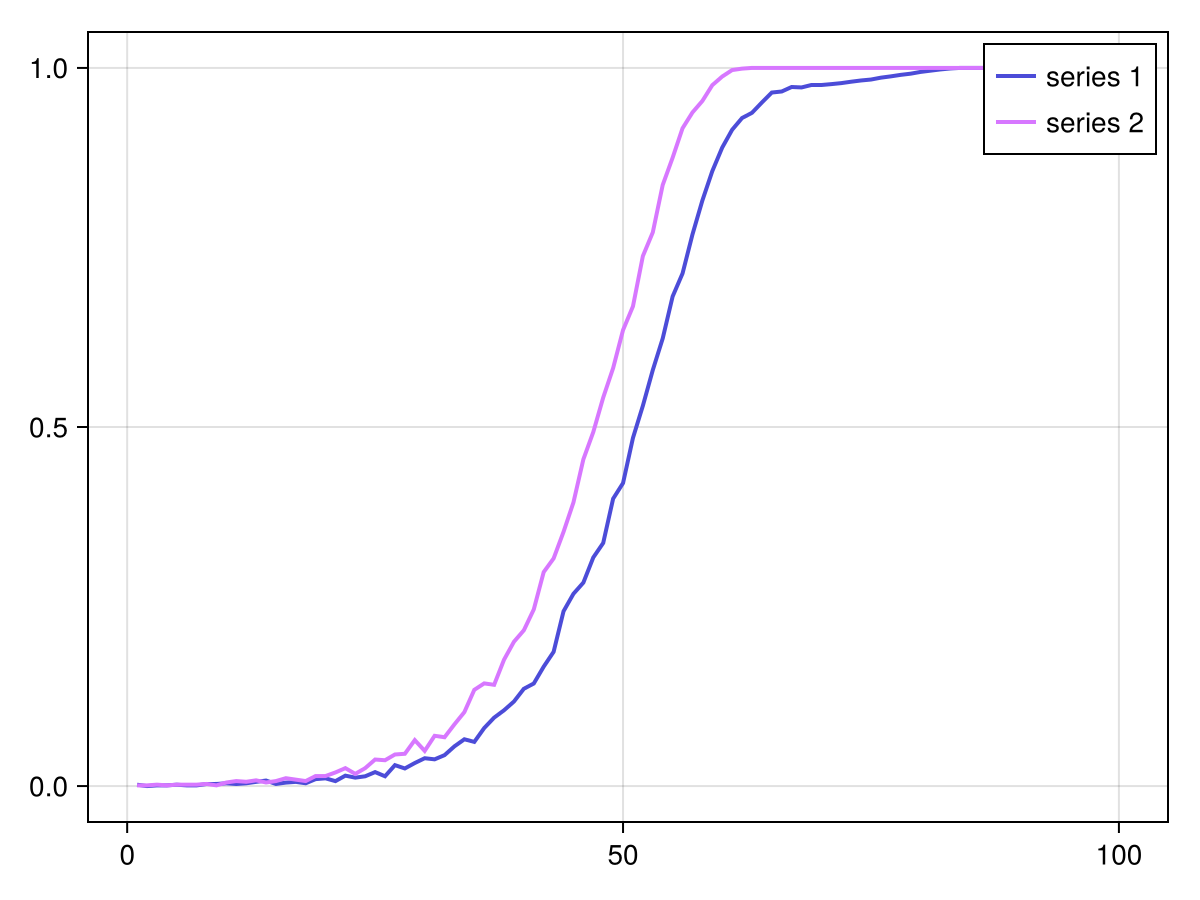

In [443]:
Nrep = 1000
Ninit = 100

inital_vec = 10 .^ range(-5,1, length = 100)

result_mat = zeros(Ninit,Nrep,2)

Threads.@threads for i = 1:Ninit
    for j = 1:Nrep
        result_mat[i,j,1] = PlantPol.simulate_network(inital_vec[i], N, M, g, edge_group, aggregated = false)
        result_mat[i,j,2] = PlantPol.simulate_network(inital_vec[i], N, M, g, edge_group, aggregated = true)
    end
end

fig,ax = series(mean(result_mat, dims = 2)[:,1,:]', label = ["Temporal","Static"])
axislegend(ax)
fig

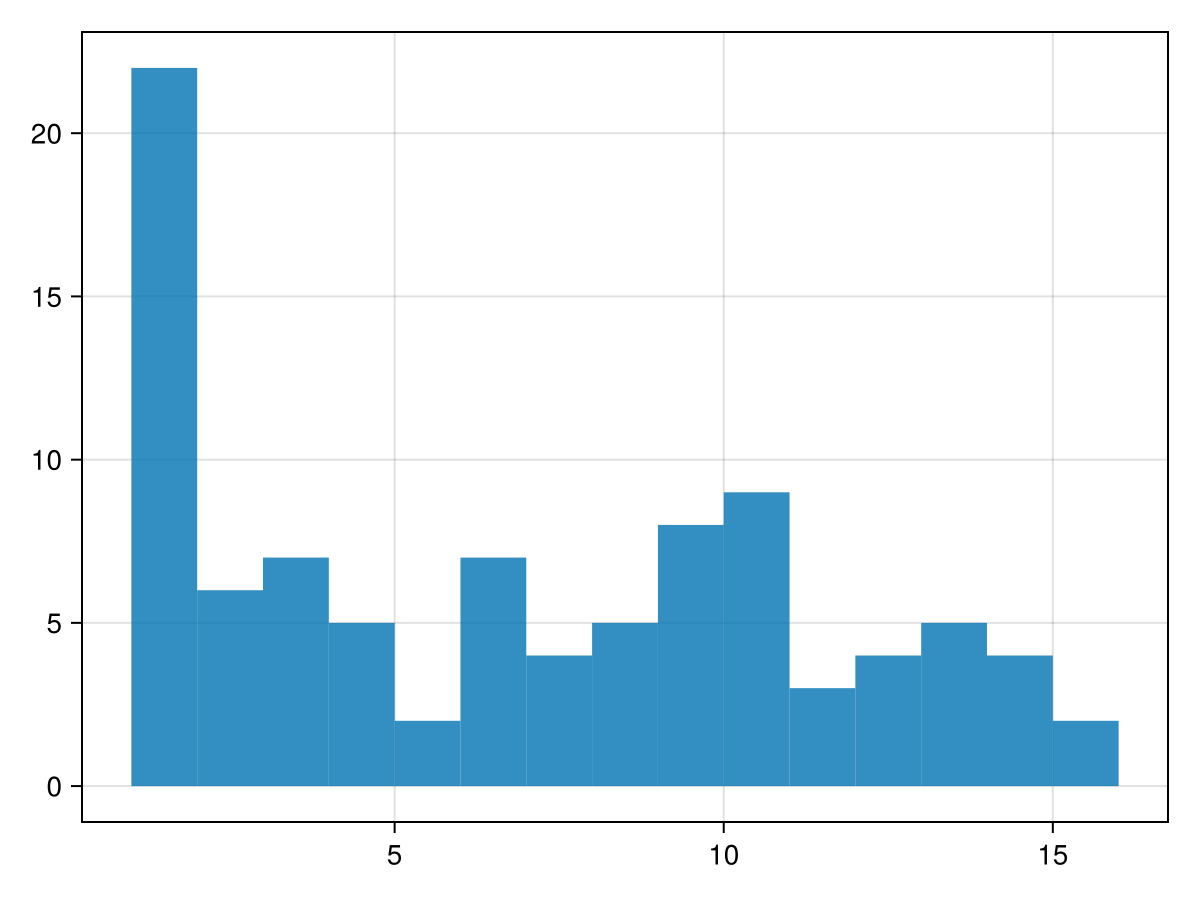

In [383]:
τ = [extrema(keys(v)) |> x -> x[2] - x[1] + 1 for (k,v) = edge_group]

hist(τ)

# Robustness and Susceptability
We have a 2d map
\begin{align}
    p &= 1-P(1-a) \\
    a &= L(1-A(1-p))
\end{align}

which has a jacobian
\begin{align}
    J = \begin{bmatrix} 0 & P'(1-a) \\ 
    L'(1-A(1-p))A'(1-p) & 0
    \end{bmatrix}
\end{align}

which has eignvalues
\begin{align}
    \lambda = \pm \sqrt{P'(1-a) L'(1-A(1-p)) A'(1-p)}
\end{align}

For poisson PGFs $F'(x) = z_f F'(x)$. Note that $L(x)$ is shifted by 1 (i.e. has an extra $x$). This gives
\begin{align}
    \lambda &= \pm \sqrt{[z_p  P(1-a)] \cdot [(\tau - \tau A(1-p) + 1)L(1-A(1-p))] \cdot [z_a A(1-p)]} \\
\end{align}

In [388]:
F(x,z) = exp(z * (x-1))

function f_λ(z_p,z_a,τ,a,p)
    u = 1 - F(1-p, z_a)
    sqrt((z_p * F(1-a,z_p)) * (z_a * F(1-p, z_a)) * (τ*u + 1)*F(u,τ))
    
end

f_λ (generic function with 1 method)

In [408]:
K = 200
z_vec = range(0.01,4.0, length = K)
l_vec = range(0.01,3.0, length = K)

λmat = similar(results_pred_a)


Threads.@threads for i = 1:K
    for j = 1:K
        λmat[i,j] = []
        z = z_vec[i]
        τ = l_vec[j]
        for (a,p) = zip(results_pred_a[i,j], results_pred_p[i,j])
            push!(λmat[i,j], 1 / (1 - f_λ(z,z,τ,a,p)))
        end
    end
end

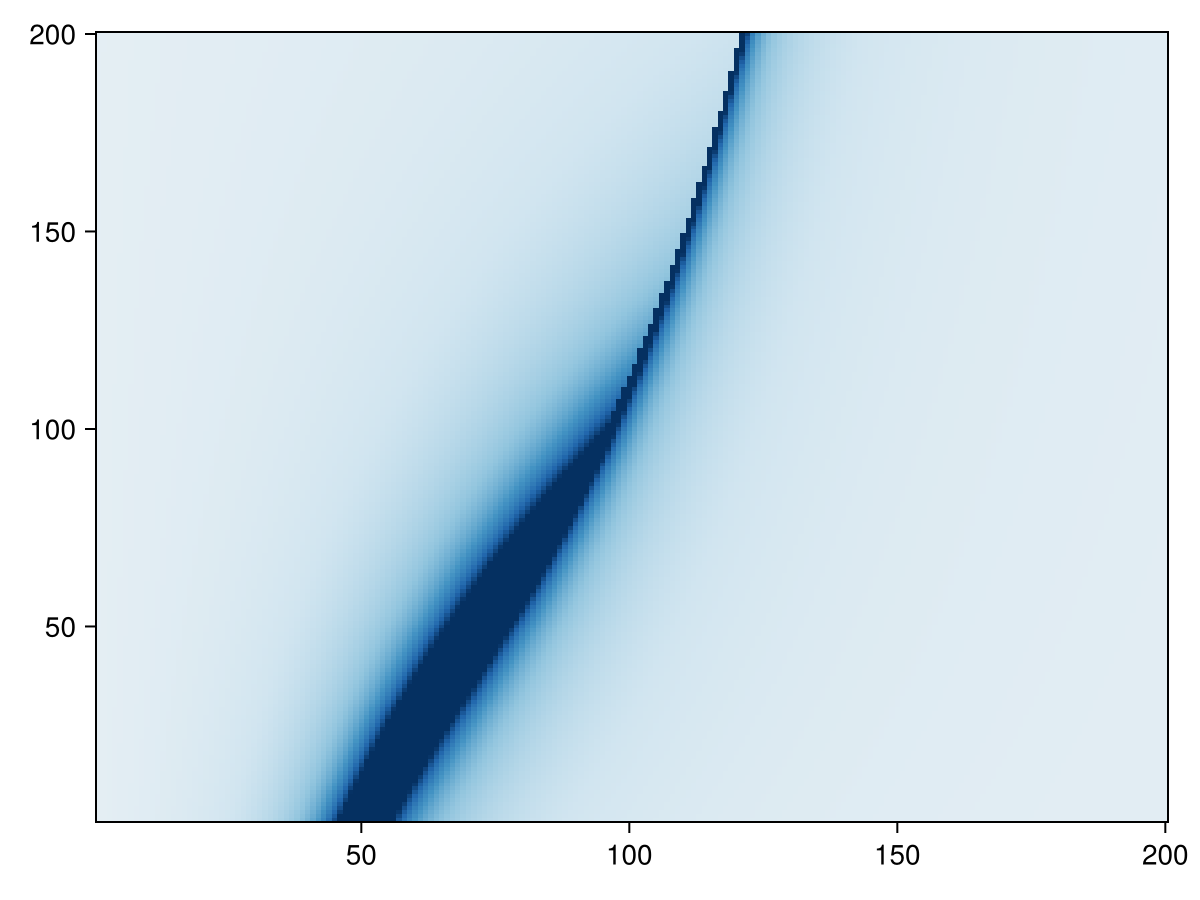

In [414]:
λ_summary = [last(λmat[i,j])  for i =1:K, j = 1:K]

heatmap(λ_summary, colorrange = (-10,10), colormap = :RdBu)

# Robustness

In [539]:
K = 100
z_vec = range(0.01,4.0, length = K)
l_vec = range(0.01,3.0, length = 5)


results_pred_robustness = Array{Any,3}(undef,K,K,5)

Threads.@threads for i = 1:K
    for j = 1:K
        for k = 1:5
            fa(x) = PlantPol.a_sol(x,z_vec[i],z_vec[j],l_vec[k])
            fp(x) = PlantPol.p_sol(x,z_vec[i],z_vec[j],l_vec[k])
    
            a_sol = find_zeros(fa, 0, 1)
            p_sol = find_zeros(fp, 0, 1)
            
            results_pred_robustness[i,j,k] = (((z_vec[i]/4.0) .* a_sol) + ((z_vec[j]/4.0) .* p_sol)) / 2
        end
    end
end

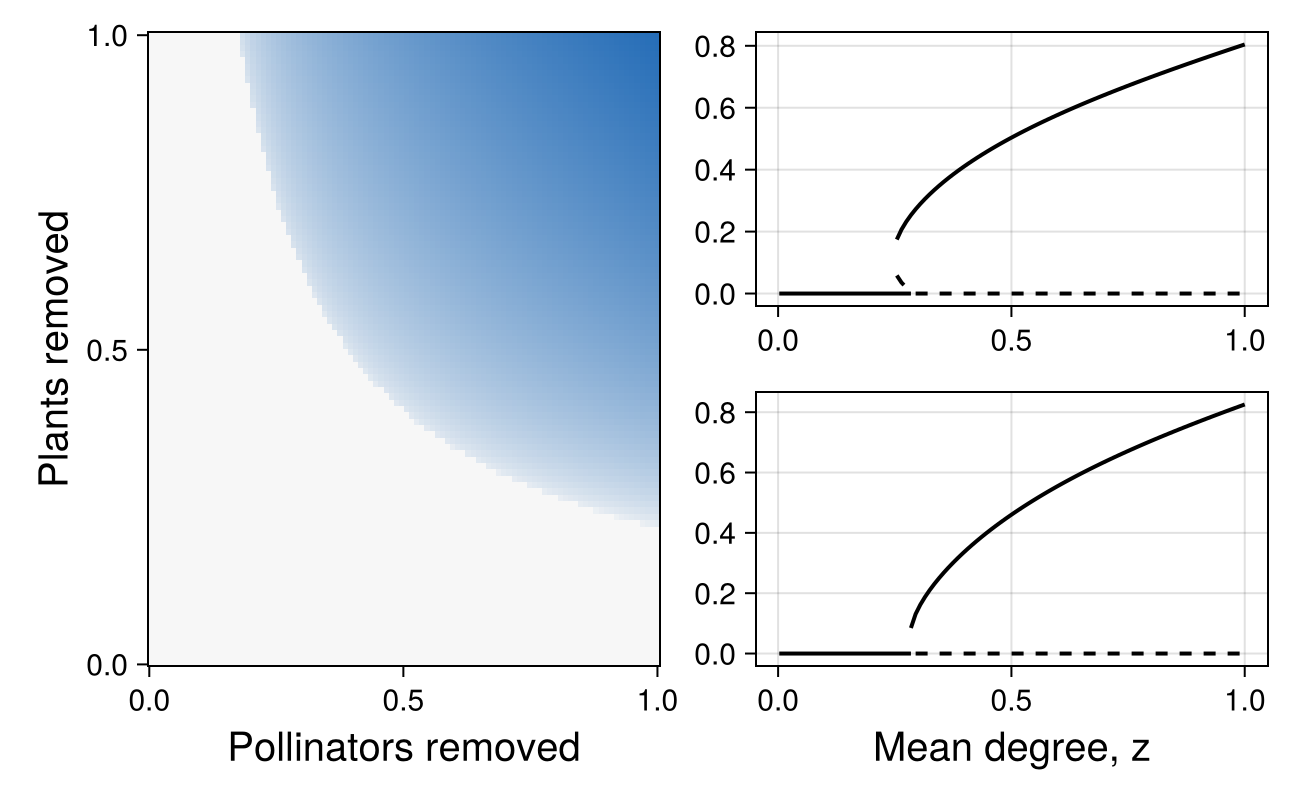

In [523]:
fig = Figure(size = (650,400))
ax = Axis(fig[1:2,1], xlabel = "Pollinators removed", ylabel = "Plants removed", xgridvisible = 0, ygridvisible = 0; style...)

c1 = RGBf(0.97,0.97,0.97)
c0 = RGBf(0.12,0.41,0.71)
cm = ColorScheme(range(c1,c0, length = 100))

#get heatmap colors
col_matrix = map(results_pred_robustness) do (res)    
    
    if length(res) != 4
        uv = maximum(res)
        r = c0.r * uv + c1.r * (1 - uv)
        g = c0.g * uv + c1.g * (1 - uv)
        b = c0.b * uv + c1.b * (1 - uv)

        return RGBf(r,g,b)
    else
        return RGBf(0.9, 0.9, 0.9)
    end
end

heatmap!(ax, z_vec ./ 4.0, z_vec ./ 4.0, col_matrix)


ax2 = Axis(fig[1,2]; style...)
PlantPol.plot_bifurcation_diagram!(ax2, z_vec / 4, results_pred_robustness[:,75], color = :black, linewidth = 2)


ax3 = Axis(fig[2,2], xlabel = "Mean degree, z"; style...)
PlantPol.plot_bifurcation_diagram!(ax3, z_vec / 4, results_pred_robustness[75,:], color = :black, linewidth = 2)



fig

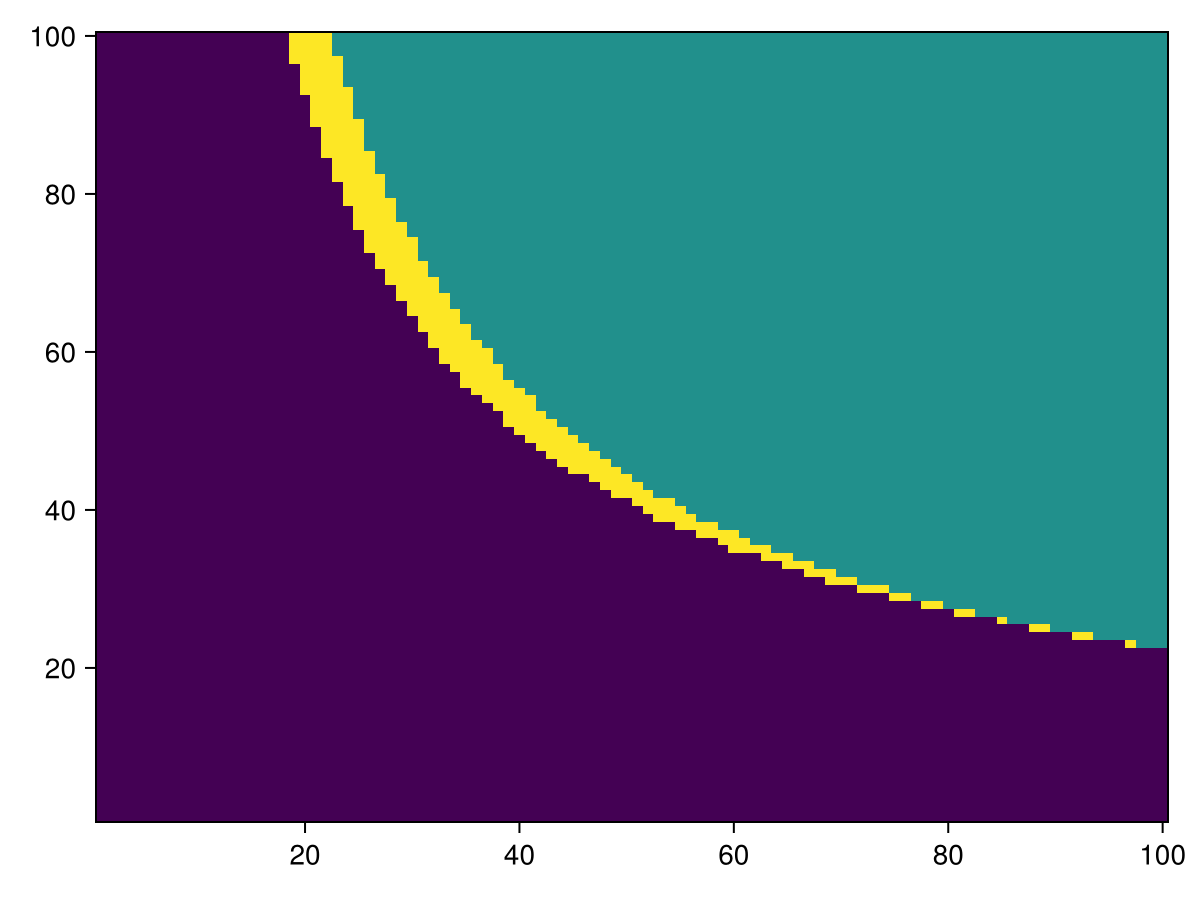

In [524]:
length.(results_pred_robustness) |> plot